# Simple Harmonic Oscillator: plain ANN vs Physics-Informed Neural Network (PINN)

**Goal.** Fit a noisy signal from a Simple Harmonic Oscillator (SHO) and forecast beyond the observed time window, comparing:

| | Plain ANN | PINN |
|---|---|---|
| Information used | Noisy data only | Noisy data **+** the governing ODE **+** initial conditions |
| Loss | $\mathcal{L} = \mathcal{L}_{data}$ | $\mathcal{L} = \mathcal{L}_{data} + \lambda_{phys}\,\mathcal{L}_{phys} + \lambda_{IC}\,\mathcal{L}_{IC}$ |

The physical system is

$$\ddot{x}(t) + \omega^2 x(t) = 0, \qquad x(t) = A\cos(\omega t + \phi)$$

**Fair comparison.** Both models share the *same* training data, test set, normalization, architecture (`SHONet`) and initial weights (same random seed). The only thing that changes is the **loss function**.

All the code lives in the `sho` package next to this notebook (`sho/data.py`, `sho/models.py`, `sho/evaluation.py`, `sho/experiment.py`). An experiment is fully described by an `SHOConfig`.

**Notebook outline**
1. Setup
2. Experimental setup & time sampling schemes
3. Single experiment: ANN vs PINN in detail
4. Sampling-scheme sweep: how does *where* we observe affect each model?

## 1. Setup

In [2]:
#%load_ext autoreload
#%autoreload 2

from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt

from sho import *  # SHOConfig, run_experiment, compare_sampling_schemes, plot_* ...

## 2. Experimental setup (shared by both models)

- **Training data:** noisy observations over `n_periods_train` periods $T = 2\pi/\omega$, at times drawn from `sampling_train`.
- **Test data:** *new* noisy observations on times **after** the training window (forecasting), with independent noise (different seed).

Every field of `SHOConfig` has a default; override only what you want to change. Derive variants with `replace(cfg, ...)` or `cfg.with_sampling(name, **kwargs)`.

In [3]:
base_cfg = SHOConfig(
    # ---- SHO parameters ----
    A=32, omega=6.0, phi=0.0,
    noise_std=0.3 * 32,          # std dev of Gaussian noise
    # ---- Training window (observed data) ----
    n_periods_train=1.0, n_points=400,
    sampling_train="uniform", sampling_train_kwargs={},
    # ---- Test window (forecasting beyond the training data) ----
    period_factor=0.5, n_test_points=100, sampling_test="uniform",
    # ---- Shared model settings (identical for ANN and PINN) ----
    hidden_sizes=(16, 32, 16, 8), model_seed=0,
    # ---- Training ----
    ann_lr=1e-3, ann_epochs=1500,
    pinn_lr=5e-5, pinn_epochs=30_000, lambda_physics=1e-3, lambda_ic=1e-3,
    n_colloc=1000, colloc_t_end=None,   # None -> collocation only on the training window
)
base_cfg

SHOConfig(A=32, omega=6.0, phi=0.0, noise_std=9.6, n_periods_train=1.0, n_points=400, sampling_train='uniform', sampling_train_kwargs={}, seed_train=42, period_factor=0.5, n_test_points=100, sampling_test='uniform', sampling_test_kwargs={}, seed_test=123, hidden_sizes=(16, 32, 16, 8), model_seed=0, normalize=True, ann_lr=0.001, ann_epochs=1500, pinn_lr=5e-05, pinn_epochs=30000, lambda_physics=0.001, lambda_ic=0.001, n_colloc=1000, colloc_t_end=None)

#### Time sampling schemes

`sample_time_points` supports the schemes below (see its docstring for the parameters). Define here the ones you want to experiment with, as `name -> (sampling, sampling_kwargs)`. The name is only a label, so the same scheme can appear several times with different parameters.

In [4]:
print(sample_time_points.__doc__)
print("Default kwargs:", SAMPLING_SCHEMES)


    Return `n_points` sorted times in [t_start, t_end] following a sampling scheme.

    sampling options (optional keyword arguments and defaults in brackets):
      "uniform"      Evenly spaced grid (np.linspace).
      "random"       i.i.d. Uniform(t_start, t_end). Equivalent to the arrival times of a
                     homogeneous Poisson process conditioned on n_points events.
      "chebyshev"    Chebyshev-Lobatto nodes: dense at both ends, sparse in the middle.
      "beta"         Beta(a, b) rescaled to the interval [a=0.5, b=0.5].
                     a=b<1 -> both ends, a=b>1 -> centre, a<b -> start, a>b -> end.
      "normal"       Truncated Gaussian [mu=midpoint, sigma=span/6].
      "exponential"  Truncated exponential, dense at start [scale=span/3, reverse=False].
                     reverse=True makes it dense at the end.
      "log"          Log-spaced grid, dense at start, like scale-factor / redshift bins
                     in cosmology [t0=span*1e-3, offset tha

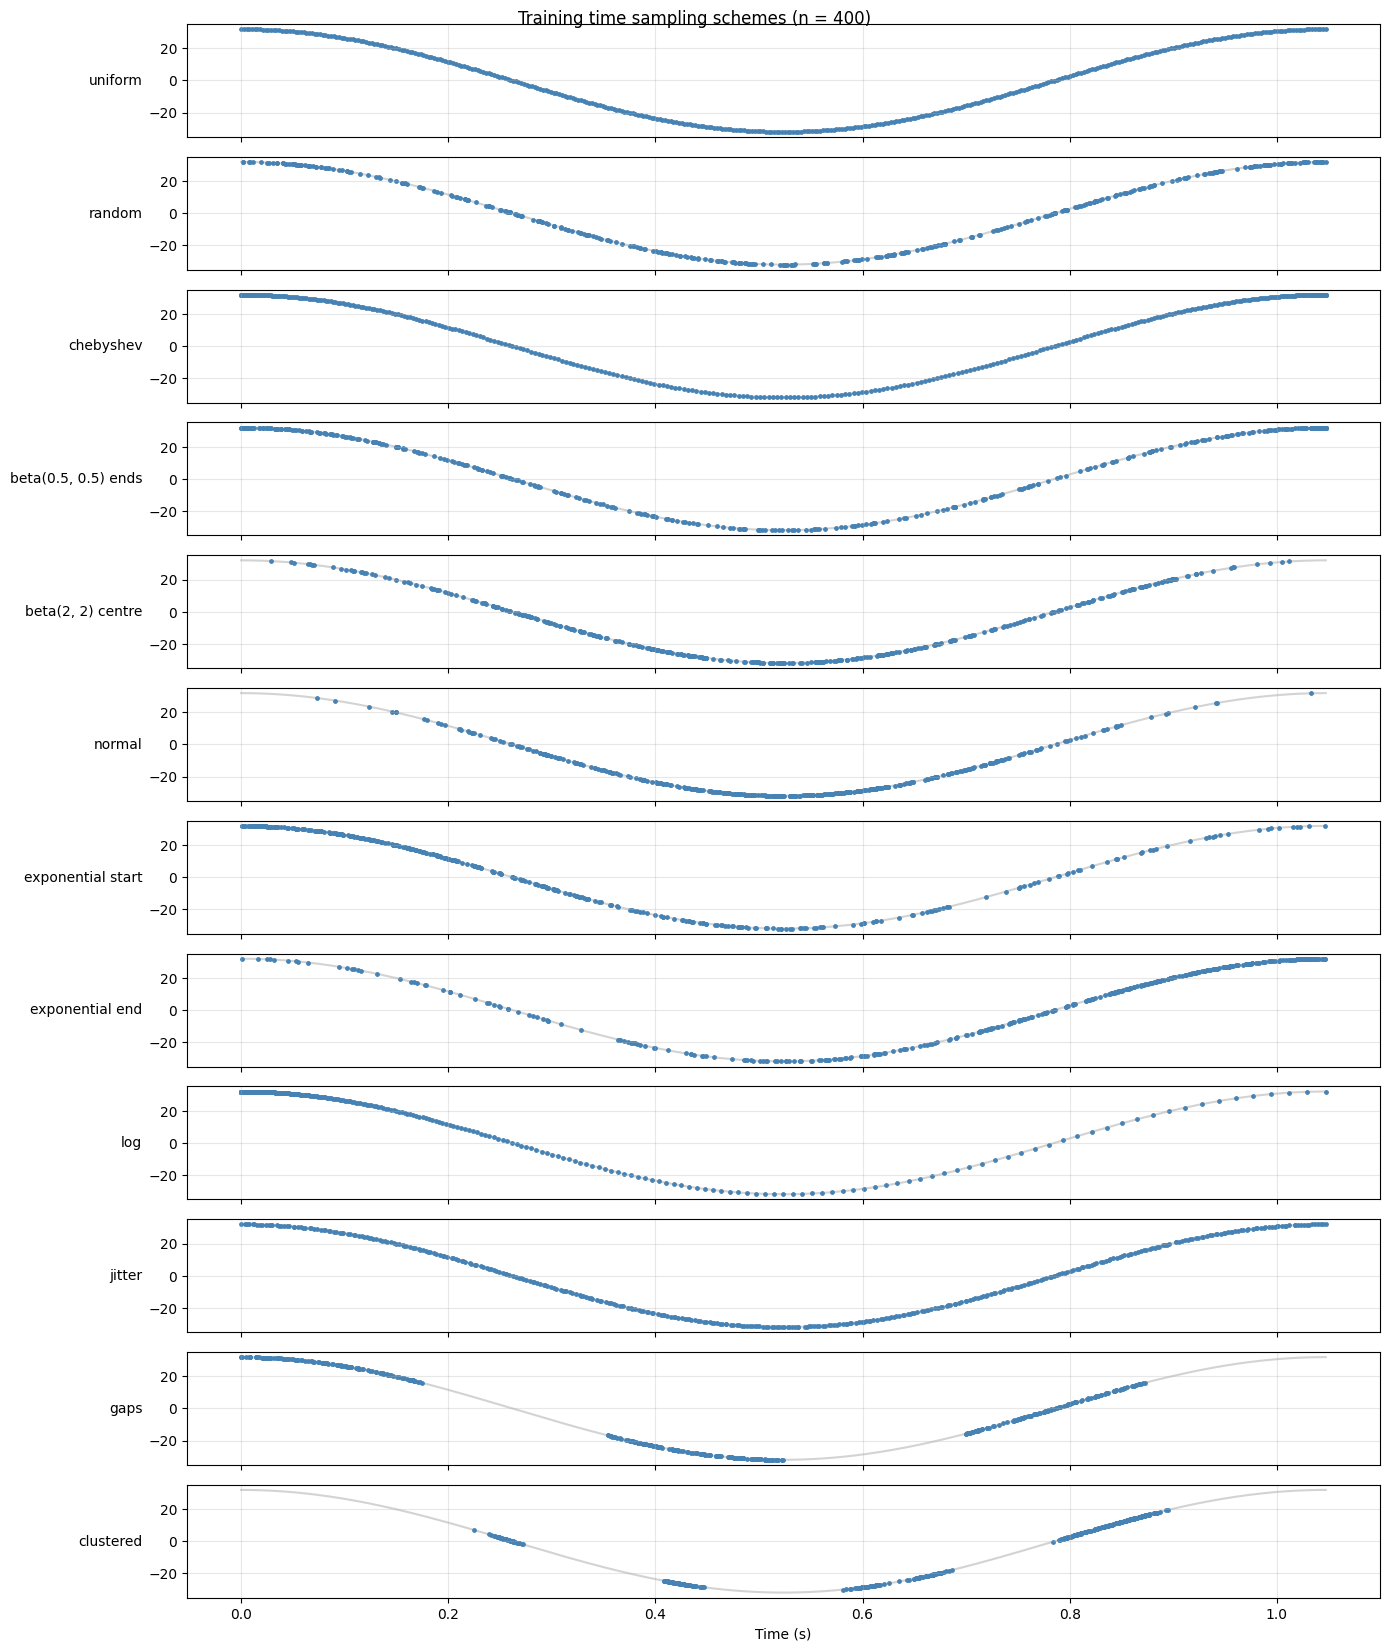

In [5]:
schemes = {
    "uniform":             ("uniform", {}),
    "random":              ("random", {}),
    "chebyshev":           ("chebyshev", {}),
    "beta(0.5, 0.5) ends": ("beta", {"a": 0.5, "b": 0.5}),
    "beta(2, 2) centre":   ("beta", {"a": 2, "b": 2}),
    "normal":              ("normal", {}),
    "exponential start":   ("exponential", {}),
    "exponential end":     ("exponential", {"reverse": True}),
    "log":                 ("log", {}),
    "jitter":              ("jitter", {"jitter": 0.3}),
    "gaps":                ("gaps", {"n_windows": 3, "duty": 0.5}),
    "clustered":           ("clustered", {"n_clusters": 8}),
    # "custom":            ("custom", {"density": lambda t: 1 + np.sin(base_cfg.omega * t)**2}),
}

plot_sampling_schemes(schemes, 0.0, base_cfg.n_periods_train * base_cfg.T, base_cfg.n_points,
                      seed=base_cfg.seed_train, A=base_cfg.A, omega=base_cfg.omega)

## 3. Single experiment: ANN vs PINN in detail

Pick one training sampling scheme and inspect everything.

In [6]:
cfg = base_cfg.with_sampling("clustered", n_clusters=8)
# cfg = replace(base_cfg, sampling_train="beta", sampling_train_kwargs={"a": 0.5, "b": 0.5})

#### Data

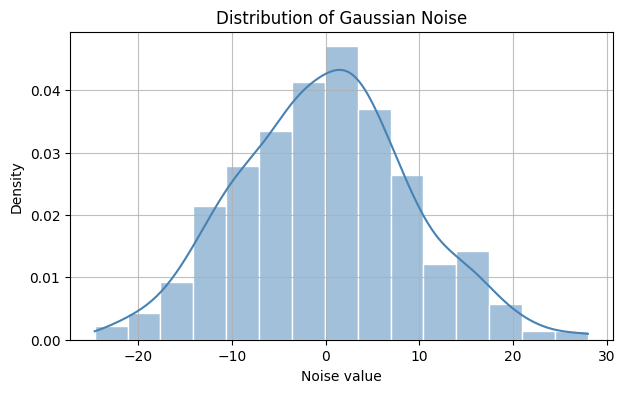

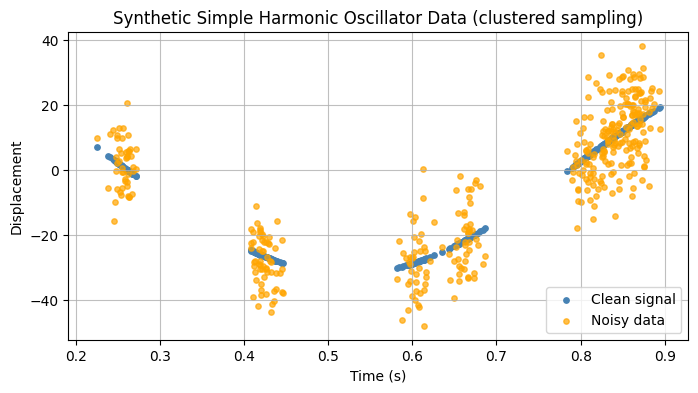

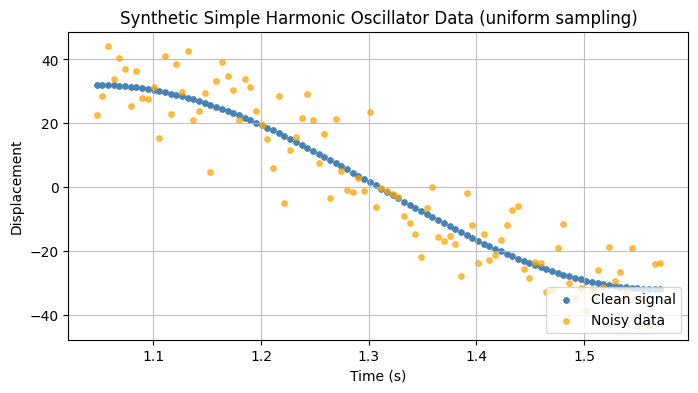

In [7]:
data = generate_data(cfg, plot=True)

#### Training both models

**Model 1: plain ANN (data only).** The network only sees the noisy observations. It minimizes

$$\mathcal{L}_{ANN} = \frac{1}{N}\sum_{i=1}^{N}\left(\hat{x}(t_i) - x_i^{noisy}\right)^2$$

Nothing tells it that the signal is an oscillator, so outside the training window it has no information to rely on.

**Model 2: PINN.** Same architecture, same data, same initial weights. The loss now also includes physics:

$$\mathcal{L}_{PINN} = \underbrace{\frac{1}{N}\sum_{i=1}^{N}\left(\hat{x}(t_i) - x_i^{noisy}\right)^2}_{\mathcal{L}_{data}}
+ \lambda_{phys}\underbrace{\frac{1}{M}\sum_{j=1}^{M}\left(\ddot{\hat{x}}(t_j) + \omega^2\hat{x}(t_j)\right)^2}_{\mathcal{L}_{phys}}
+ \lambda_{IC}\underbrace{\left[(\hat{x}(0)-x_0)^2 + (\dot{\hat{x}}(0)-v_0)^2\right]}_{\mathcal{L}_{IC}}$$

- $\mathcal{L}_{phys}$ is evaluated on **collocation points** $t_j$. These don't need measurements, so they can extend beyond the data window (`colloc_t_end`).
- $\mathcal{L}_{IC}$ uses the known initial state of the oscillator.

In [8]:
res = run_experiment(cfg, verbose=True)
print(res.model_ann)

[clustered] Training ANN ...
Epoch 300/1500, Loss: 0.212303
Epoch 600/1500, Loss: 0.207598
Epoch 900/1500, Loss: 0.207333
Epoch 1200/1500, Loss: 0.207201
Epoch 1500/1500, Loss: 0.207078
[clustered] Training PINN ...
Epoch 3000/30000 | Total: 2.03368 | Data: 1.01912 | Physics: 16.73107 | IC: 997.83112
Epoch 6000/30000 | Total: 2.00387 | Data: 0.99951 | Physics: 28.48096 | IC: 975.88019
Epoch 9000/30000 | Total: 1.07511 | Data: 0.56416 | Physics: 80.53918 | IC: 430.41354
Epoch 12000/30000 | Total: 0.21459 | Data: 0.21119 | Physics: 2.89715 | IC: 0.50367
Epoch 15000/30000 | Total: 0.21119 | Data: 0.20945 | Physics: 1.62666 | IC: 0.12223
Epoch 18000/30000 | Total: 0.21079 | Data: 0.20943 | Physics: 1.23262 | IC: 0.12954
Epoch 21000/30000 | Total: 0.21054 | Data: 0.20942 | Physics: 0.98515 | IC: 0.13404
Epoch 24000/30000 | Total: 0.21041 | Data: 0.20942 | Physics: 0.84740 | IC: 0.13823
Epoch 27000/30000 | Total: 0.21051 | Data: 0.20941 | Physics: 0.97102 | IC: 0.12672
Epoch 30000/30000 | To

### 3.1 Model 1 — Plain ANN

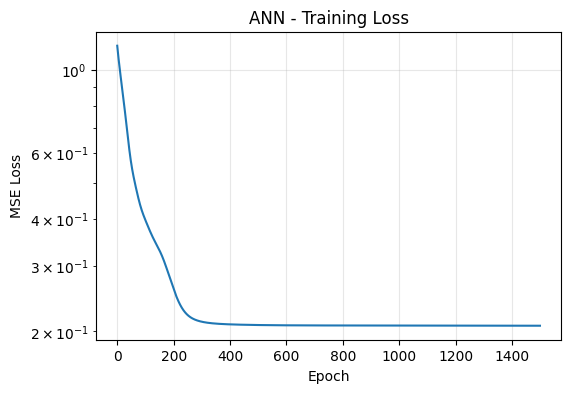

In [9]:
plot_ann_loss(res)

#### Training set fit

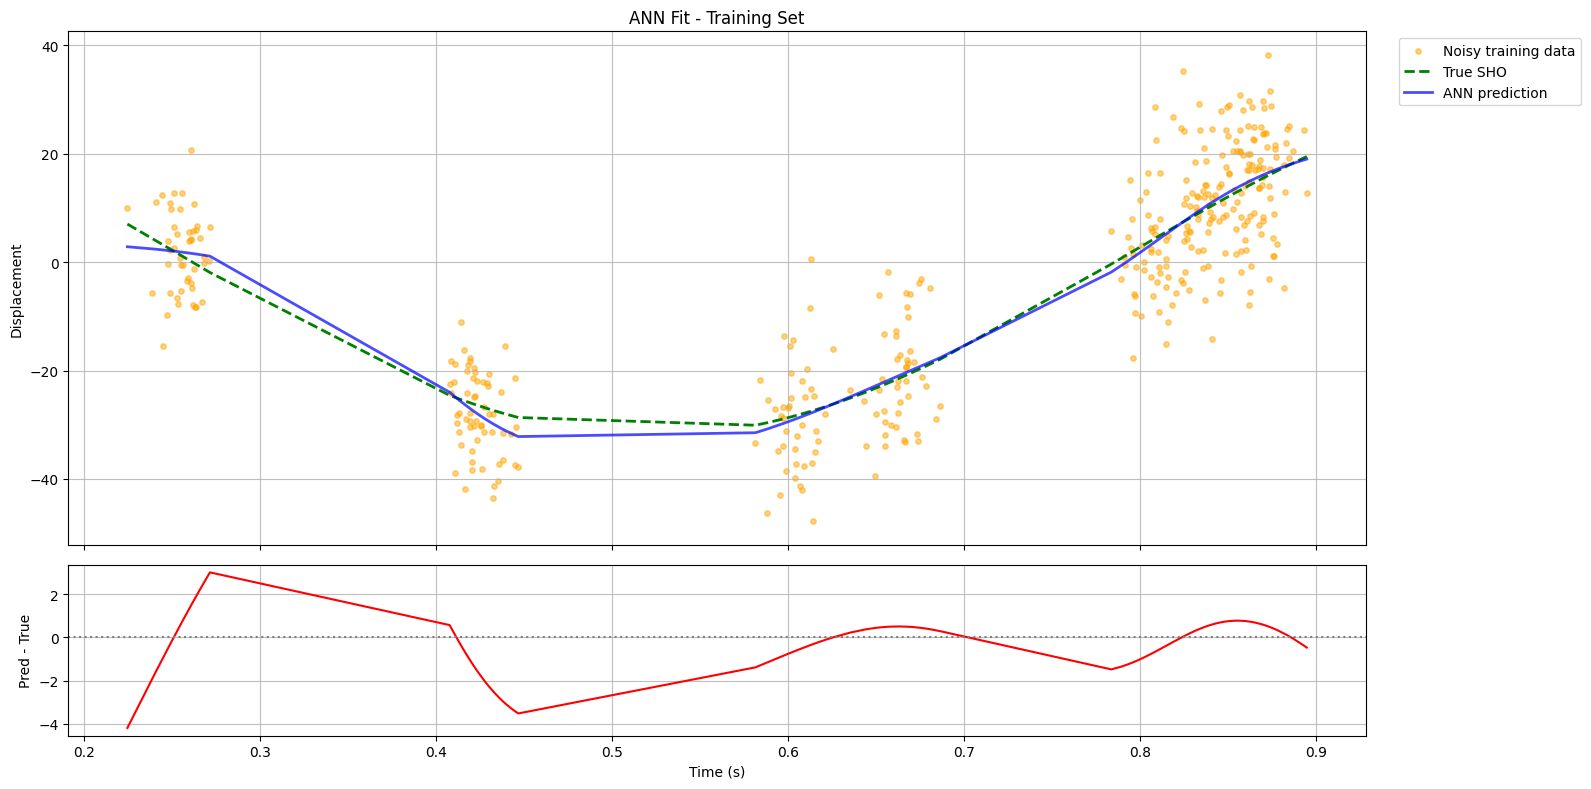

In [10]:
plot_model_fit(res, "ann", "train")

#### Test set (forecasting)

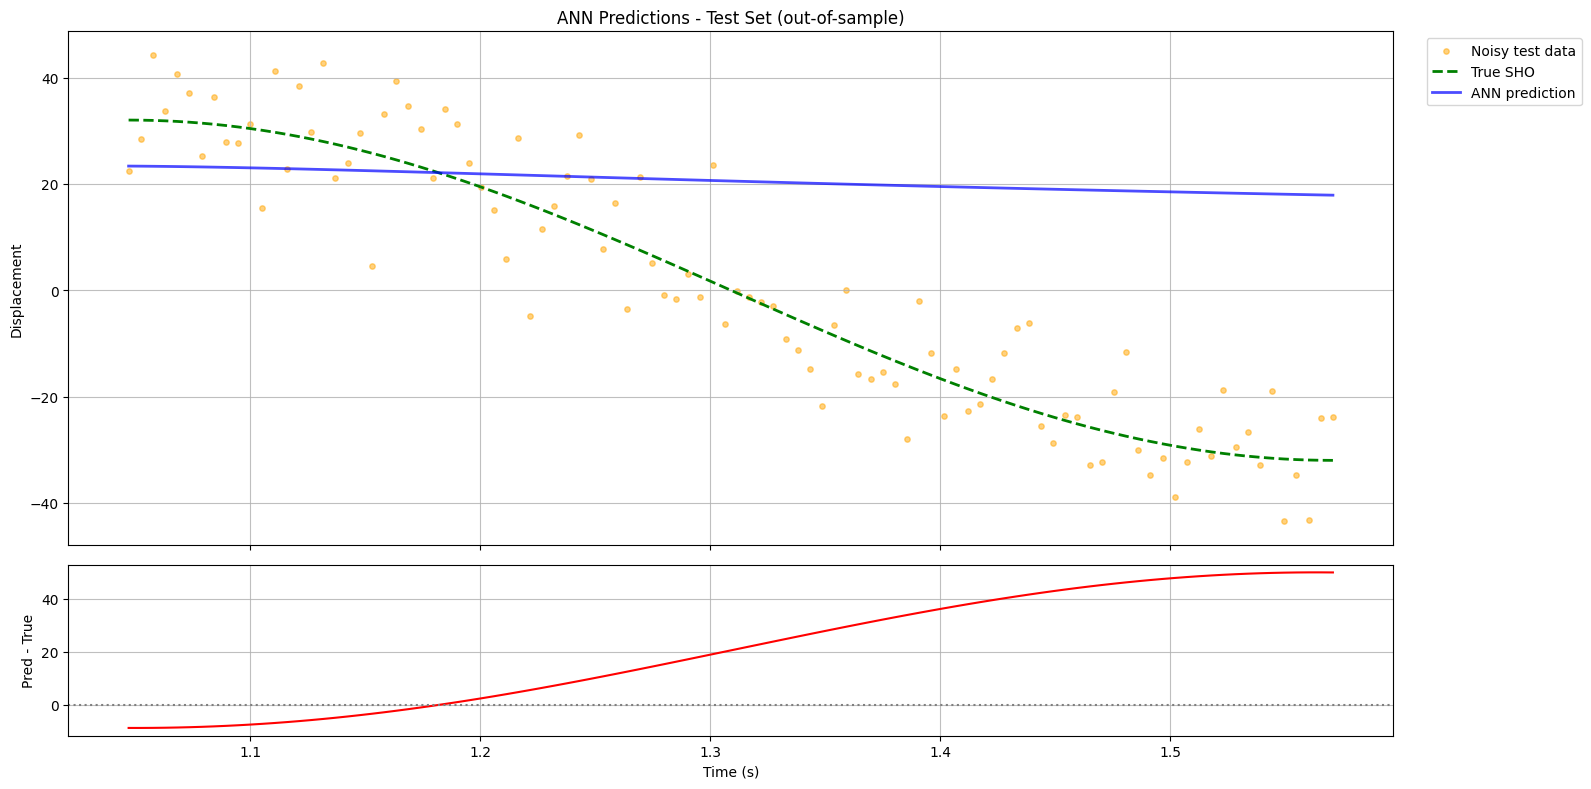

In [11]:
plot_model_fit(res, "ann", "test")

### 3.2 Model 2 — PINN

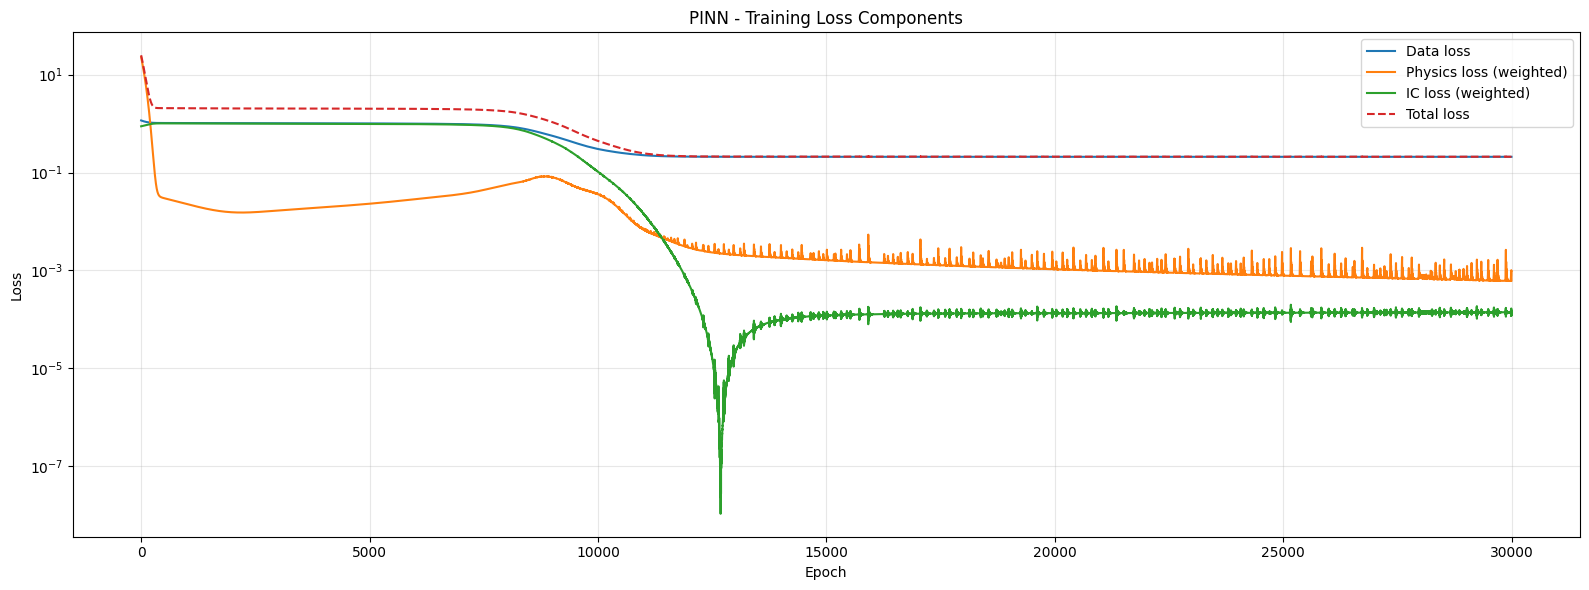

In [12]:
plot_pinn_losses(res)

#### Training set fit

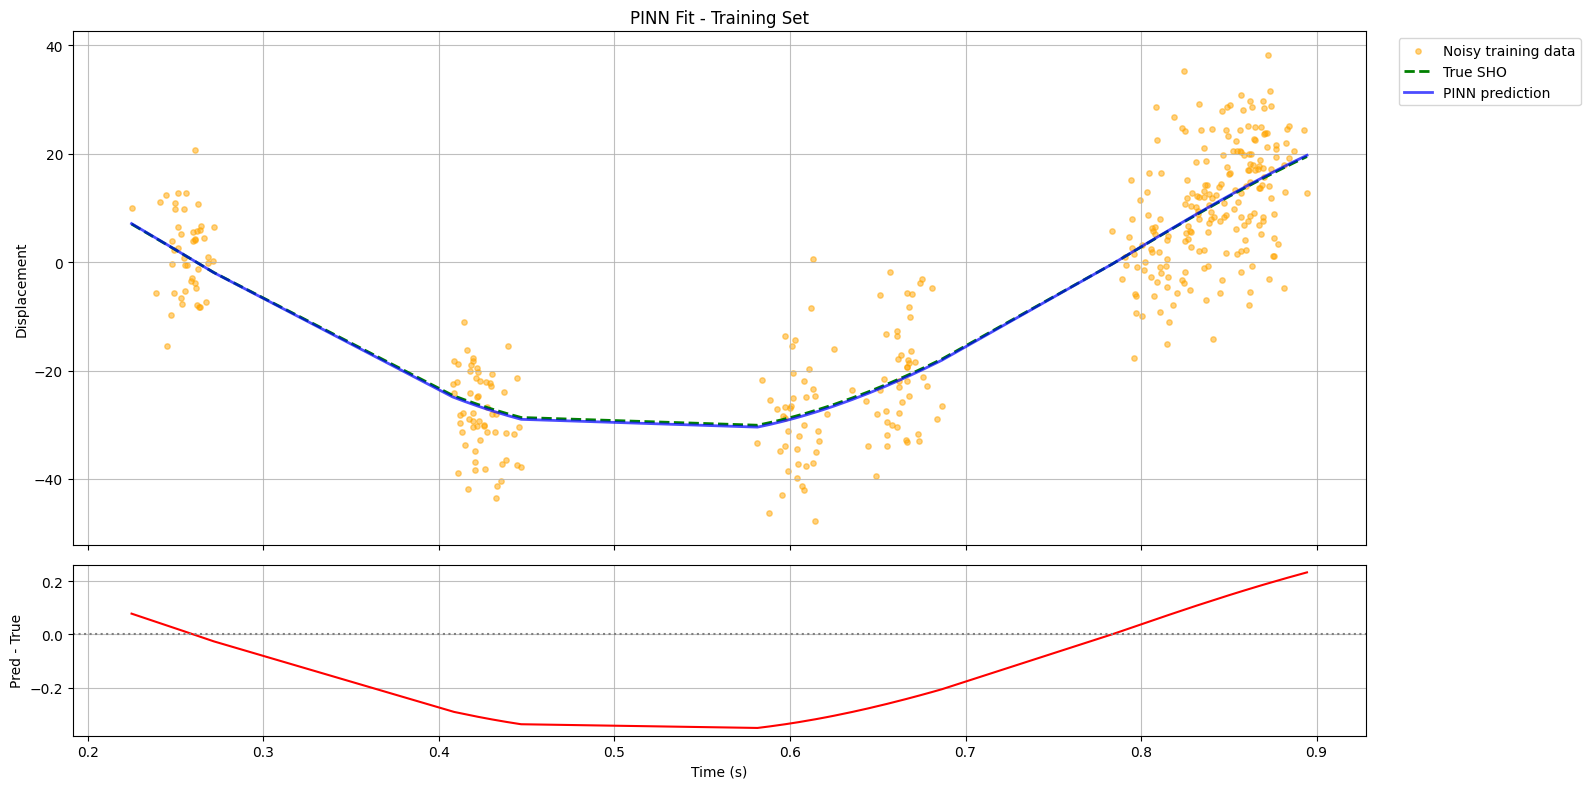

In [13]:
plot_model_fit(res, "pinn", "train")

#### Test set (forecasting)

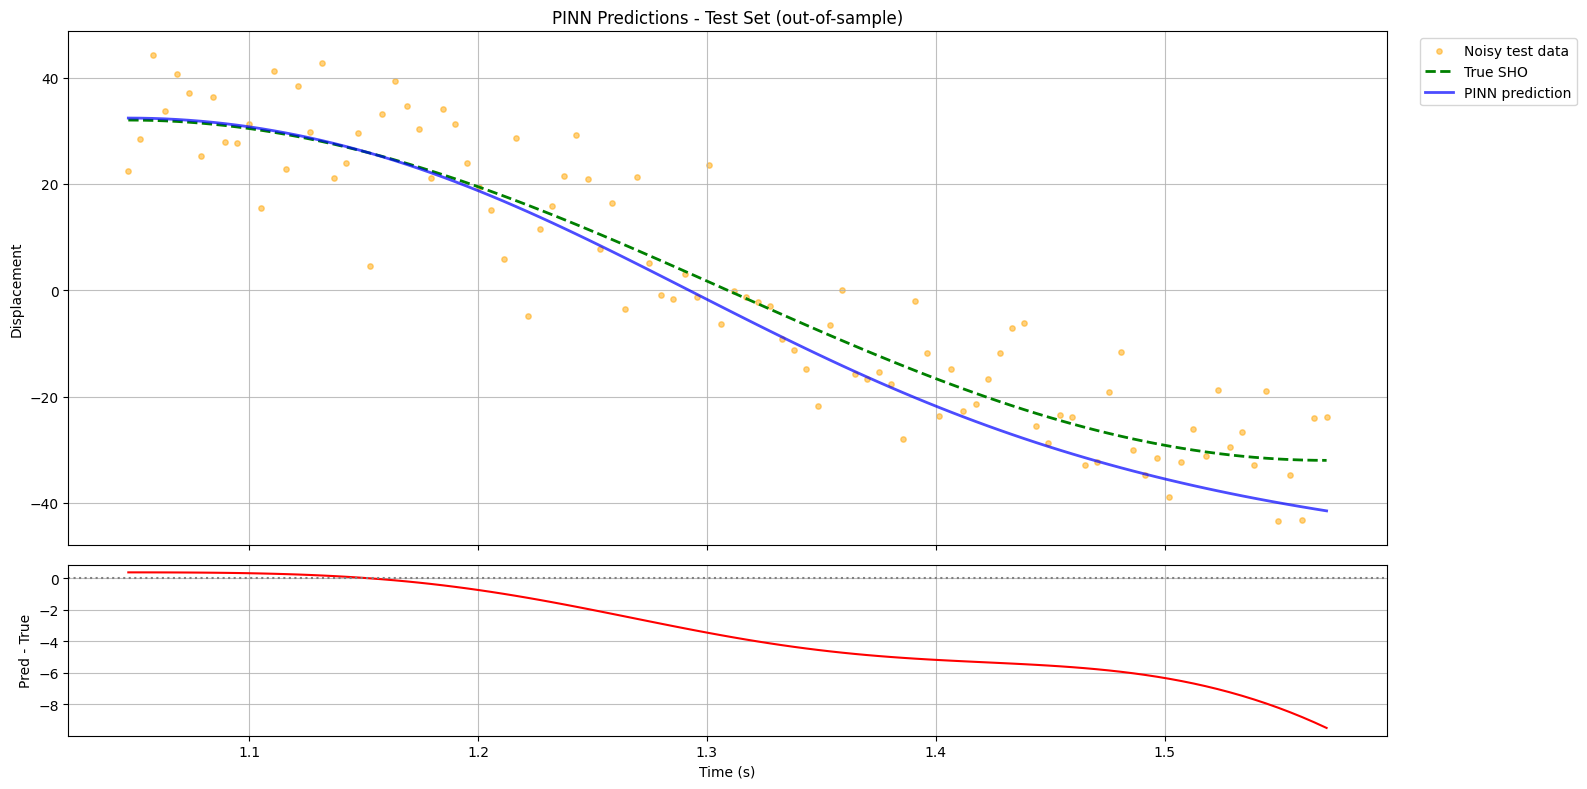

In [14]:
plot_model_fit(res, "pinn", "test")

### 3.3 ANN vs PINN — head-to-head

Several views of the same question: *did the model learn the oscillator, or just the data?*
1. **Data loss vs noise floor:** how closely each model chases the noisy points.
2. **Predictions over training + test windows.**
3. **Prediction error over time**, against the true signal.
4. **Physical consistency:** how well each model satisfies $\ddot{x} + \omega^2 x = 0$.
5. **Metrics table.**

#### 1. Data loss vs noise floor
With independent Gaussian noise, a model that recovers the *true* signal cannot push the data MSE below the noise variance (in normalized units: $(\sigma_{noise}/\sigma_x)^2$). A data loss **below** this floor means the model is fitting the noise.

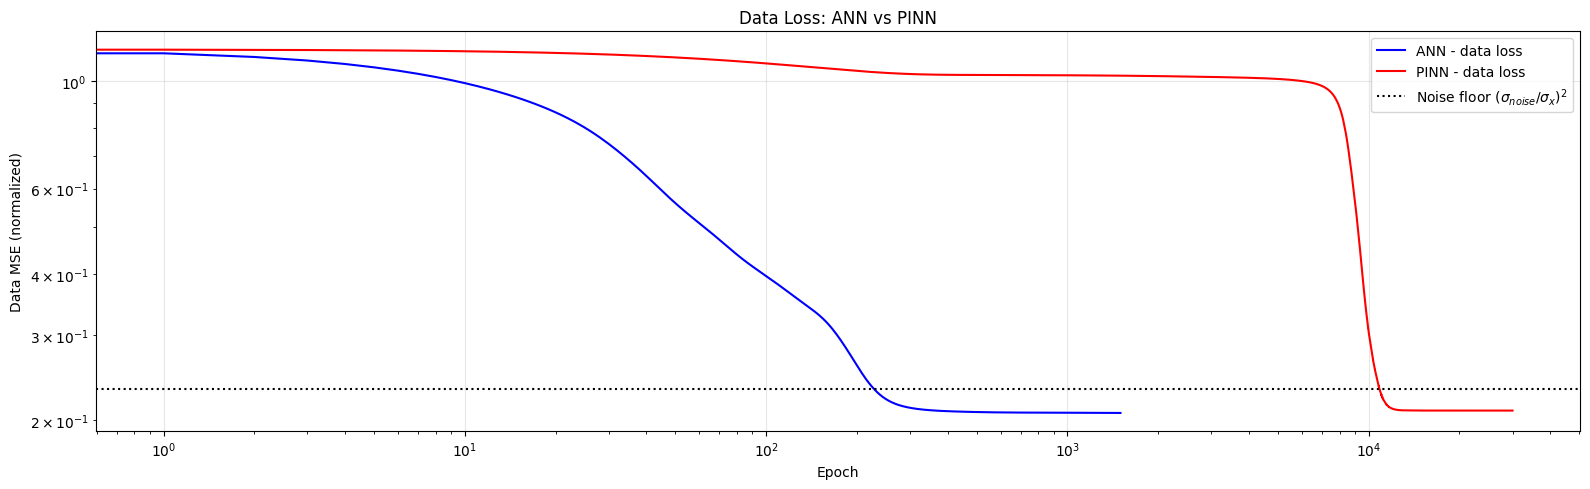

In [15]:
plot_data_loss_vs_noise_floor(res)

#### 2. Predictions over training + test windows

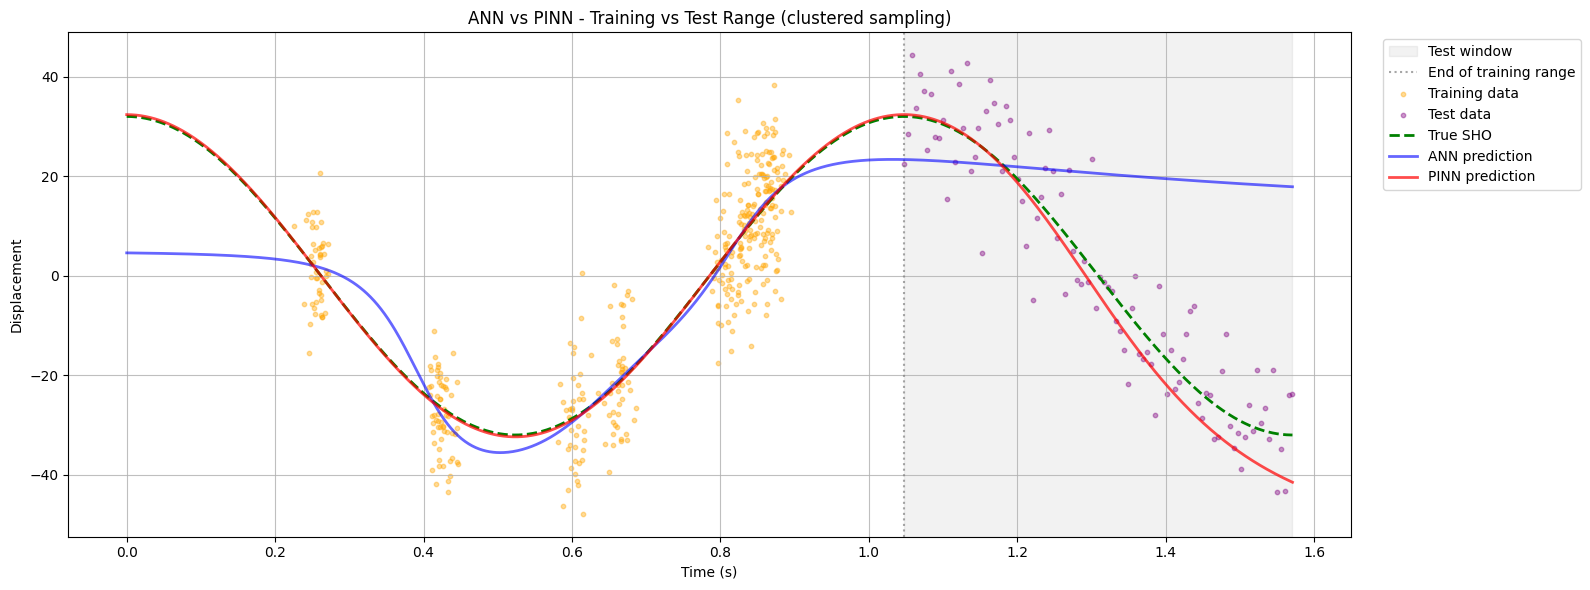

In [16]:
plot_predictions_full(res)

#### 3. Prediction error over time (vs true signal)

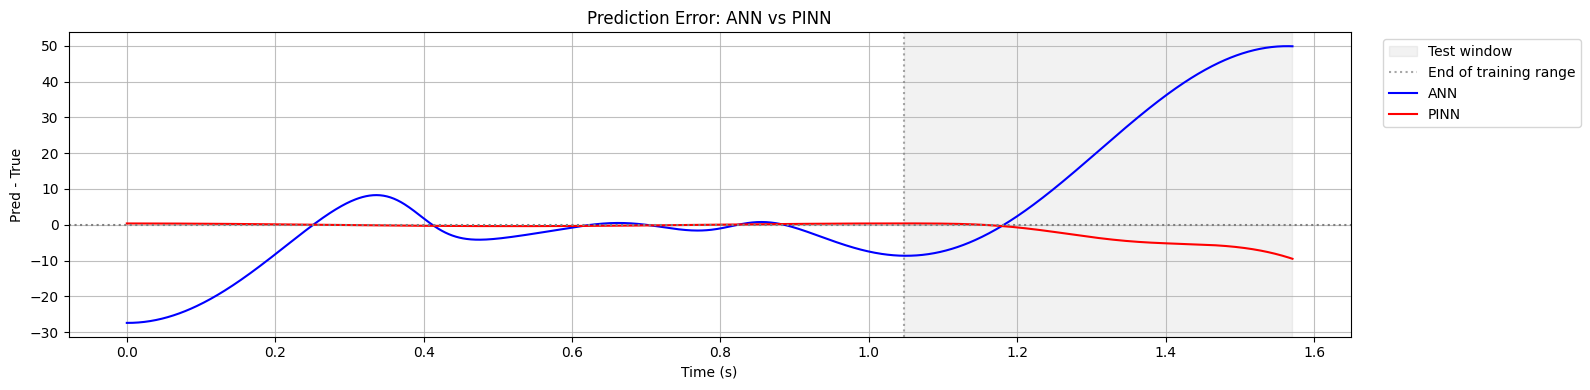

In [17]:
plot_error_full(res)

#### 4. Physical consistency
Evaluate the ODE residual $r(t) = \ddot{\hat{x}} + \omega^2 \hat{x}$ of **both** trained models over the full time range. The true solution has $r(t) = 0$ everywhere. The ANN was never asked to satisfy this, so it measures how "physical" a purely data-driven fit is.

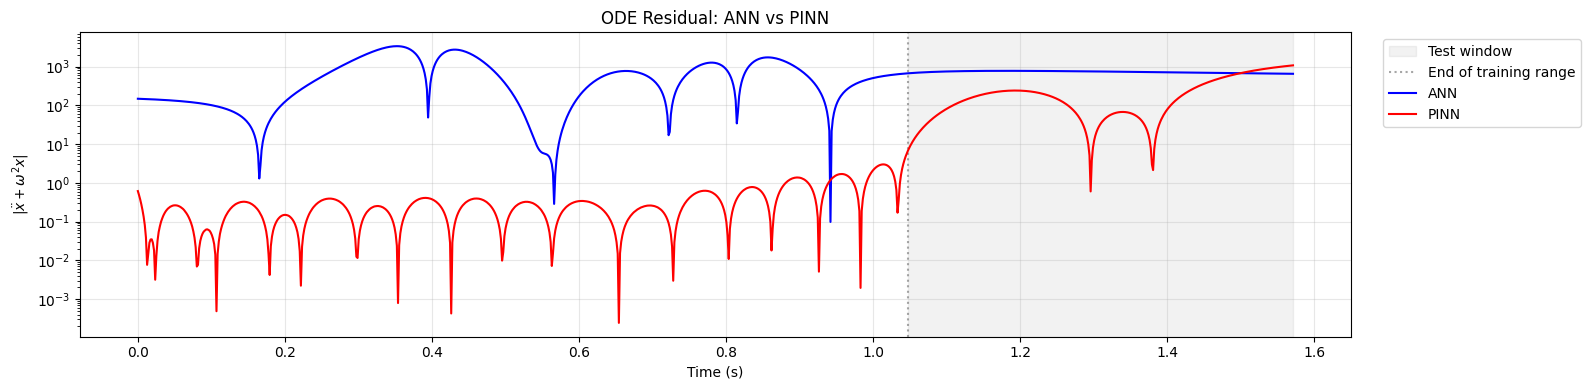

In [18]:
plot_ode_residual(res)

#### 5. Metrics

In [19]:
display(res.metrics.round(4))
display(res.physics_rms.to_frame().round(4))

ANN                               PINN                  \
                       MSE     RMSE      MAE      R2      MSE    RMSE     MAE   
Train (vs noisy)   82.2823   9.0710   7.1979  0.7924  83.2109  9.1220  7.2578   
Train (vs true)     1.0995   1.0486   0.8068  0.9963   0.0432  0.2078  0.1776   
Test (vs noisy)   924.0668  30.3985  25.0212 -0.5233  96.5239  9.8247  7.6002   
Test (vs true)    867.4481  29.4525  23.6516 -0.6775  19.1648  4.3778  3.4525   

                          
                      R2  
Train (vs noisy)  0.7901  
Train (vs true)   0.9999  
Test (vs noisy)   0.8409  
Test (vs true)    0.9629

,ODE residual RMS
ANN,1021.579895
PINN,227.509903


## 4. Sampling-scheme sweep

Same SHO, same noise, same test set, same initial weights: only the **training time sampling** changes. Each scheme trains one ANN and one PINN, so the cost is `len(schemes)` × (ANN + PINN) trainings. Lower `pinn_epochs` in `sweep_cfg` for a quick first look.

In [20]:
sweep_cfg = replace(base_cfg, pinn_epochs=30_000)
sweep_schemes = schemes  # or a subset, e.g. {k: schemes[k] for k in ["uniform", "gaps", "clustered"]}

results, summary = compare_sampling_schemes(sweep_cfg, sweep_schemes)

Running uniform ...
Running random ...
Running chebyshev ...
Running beta(0.5, 0.5) ends ...
Running beta(2, 2) centre ...
Running normal ...
Running exponential start ...
Running exponential end ...
Running log ...
Running jitter ...
Running gaps ...
Running clustered ...


#### Summary (all metrics against the true signal)

In [21]:
display(summary.round(4))

,Train RMSE (vs true),Test RMSE (vs true),Test R2 (vs true),ODE residual RMS,Train RMSE (vs true),Test RMSE (vs true),Test R2 (vs true),ODE residual RMS
,ANN,ANN,ANN,ANN,PINN,PINN,PINN,PINN
uniform,0.9859,46.4773,-3.1772,816.844177,0.0842,8.3213,0.8661,333.699402
random,1.0542,47.0944,-3.2889,829.929199,0.0469,9.7269,0.8170,358.150391
chebyshev,1.0326,46.2619,-3.1386,815.115173,0.1106,10.7786,0.7753,391.080200
"beta(0.5, 0.5) ends",1.0115,47.0357,-3.2782,823.475403,0.1149,10.9314,0.7689,395.422791
"beta(2, 2) centre",0.9765,48.1163,-3.4771,862.980103,0.1016,9.4941,0.8257,329.190308
normal,0.9306,43.6149,-2.6786,763.653015,0.0580,5.8630,0.9335,271.277588
exponential start,0.8484,48.6161,-3.5706,852.428284,0.3222,6.7889,0.9109,324.350586
exponential end,0.9792,26.8738,-0.3966,518.503113,0.2217,3.9768,0.9694,246.325699
log,1.2778,53.6367,-4.5633,962.581421,0.3800,4.7419,0.9565,288.429688


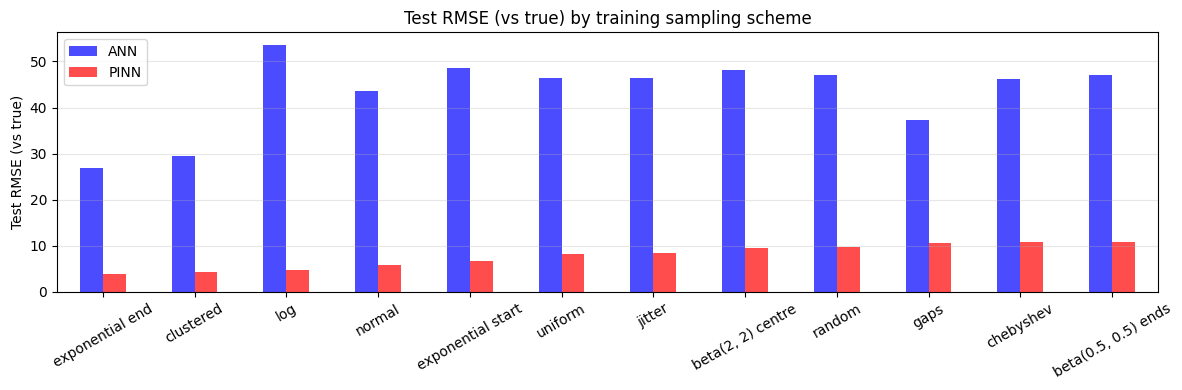

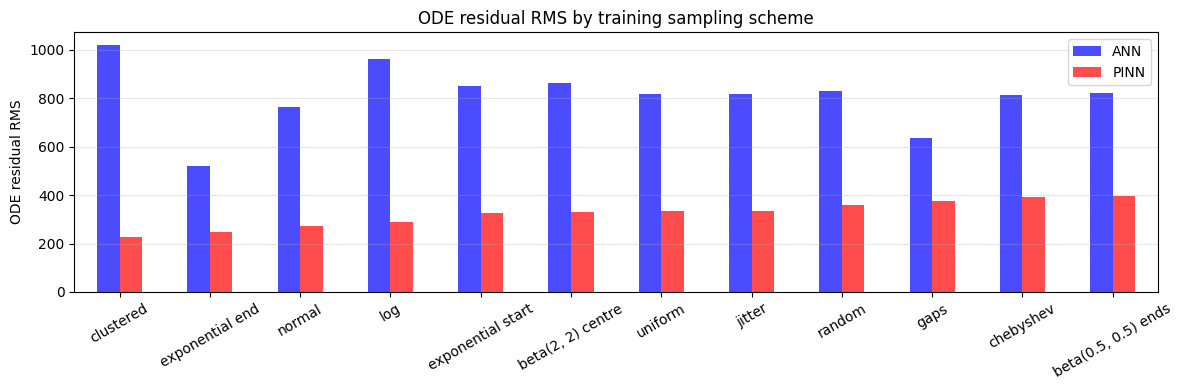

In [22]:
plot_summary_bars(summary, "Test RMSE (vs true)")
plot_summary_bars(summary, "ODE residual RMS")

#### Predictions per scheme

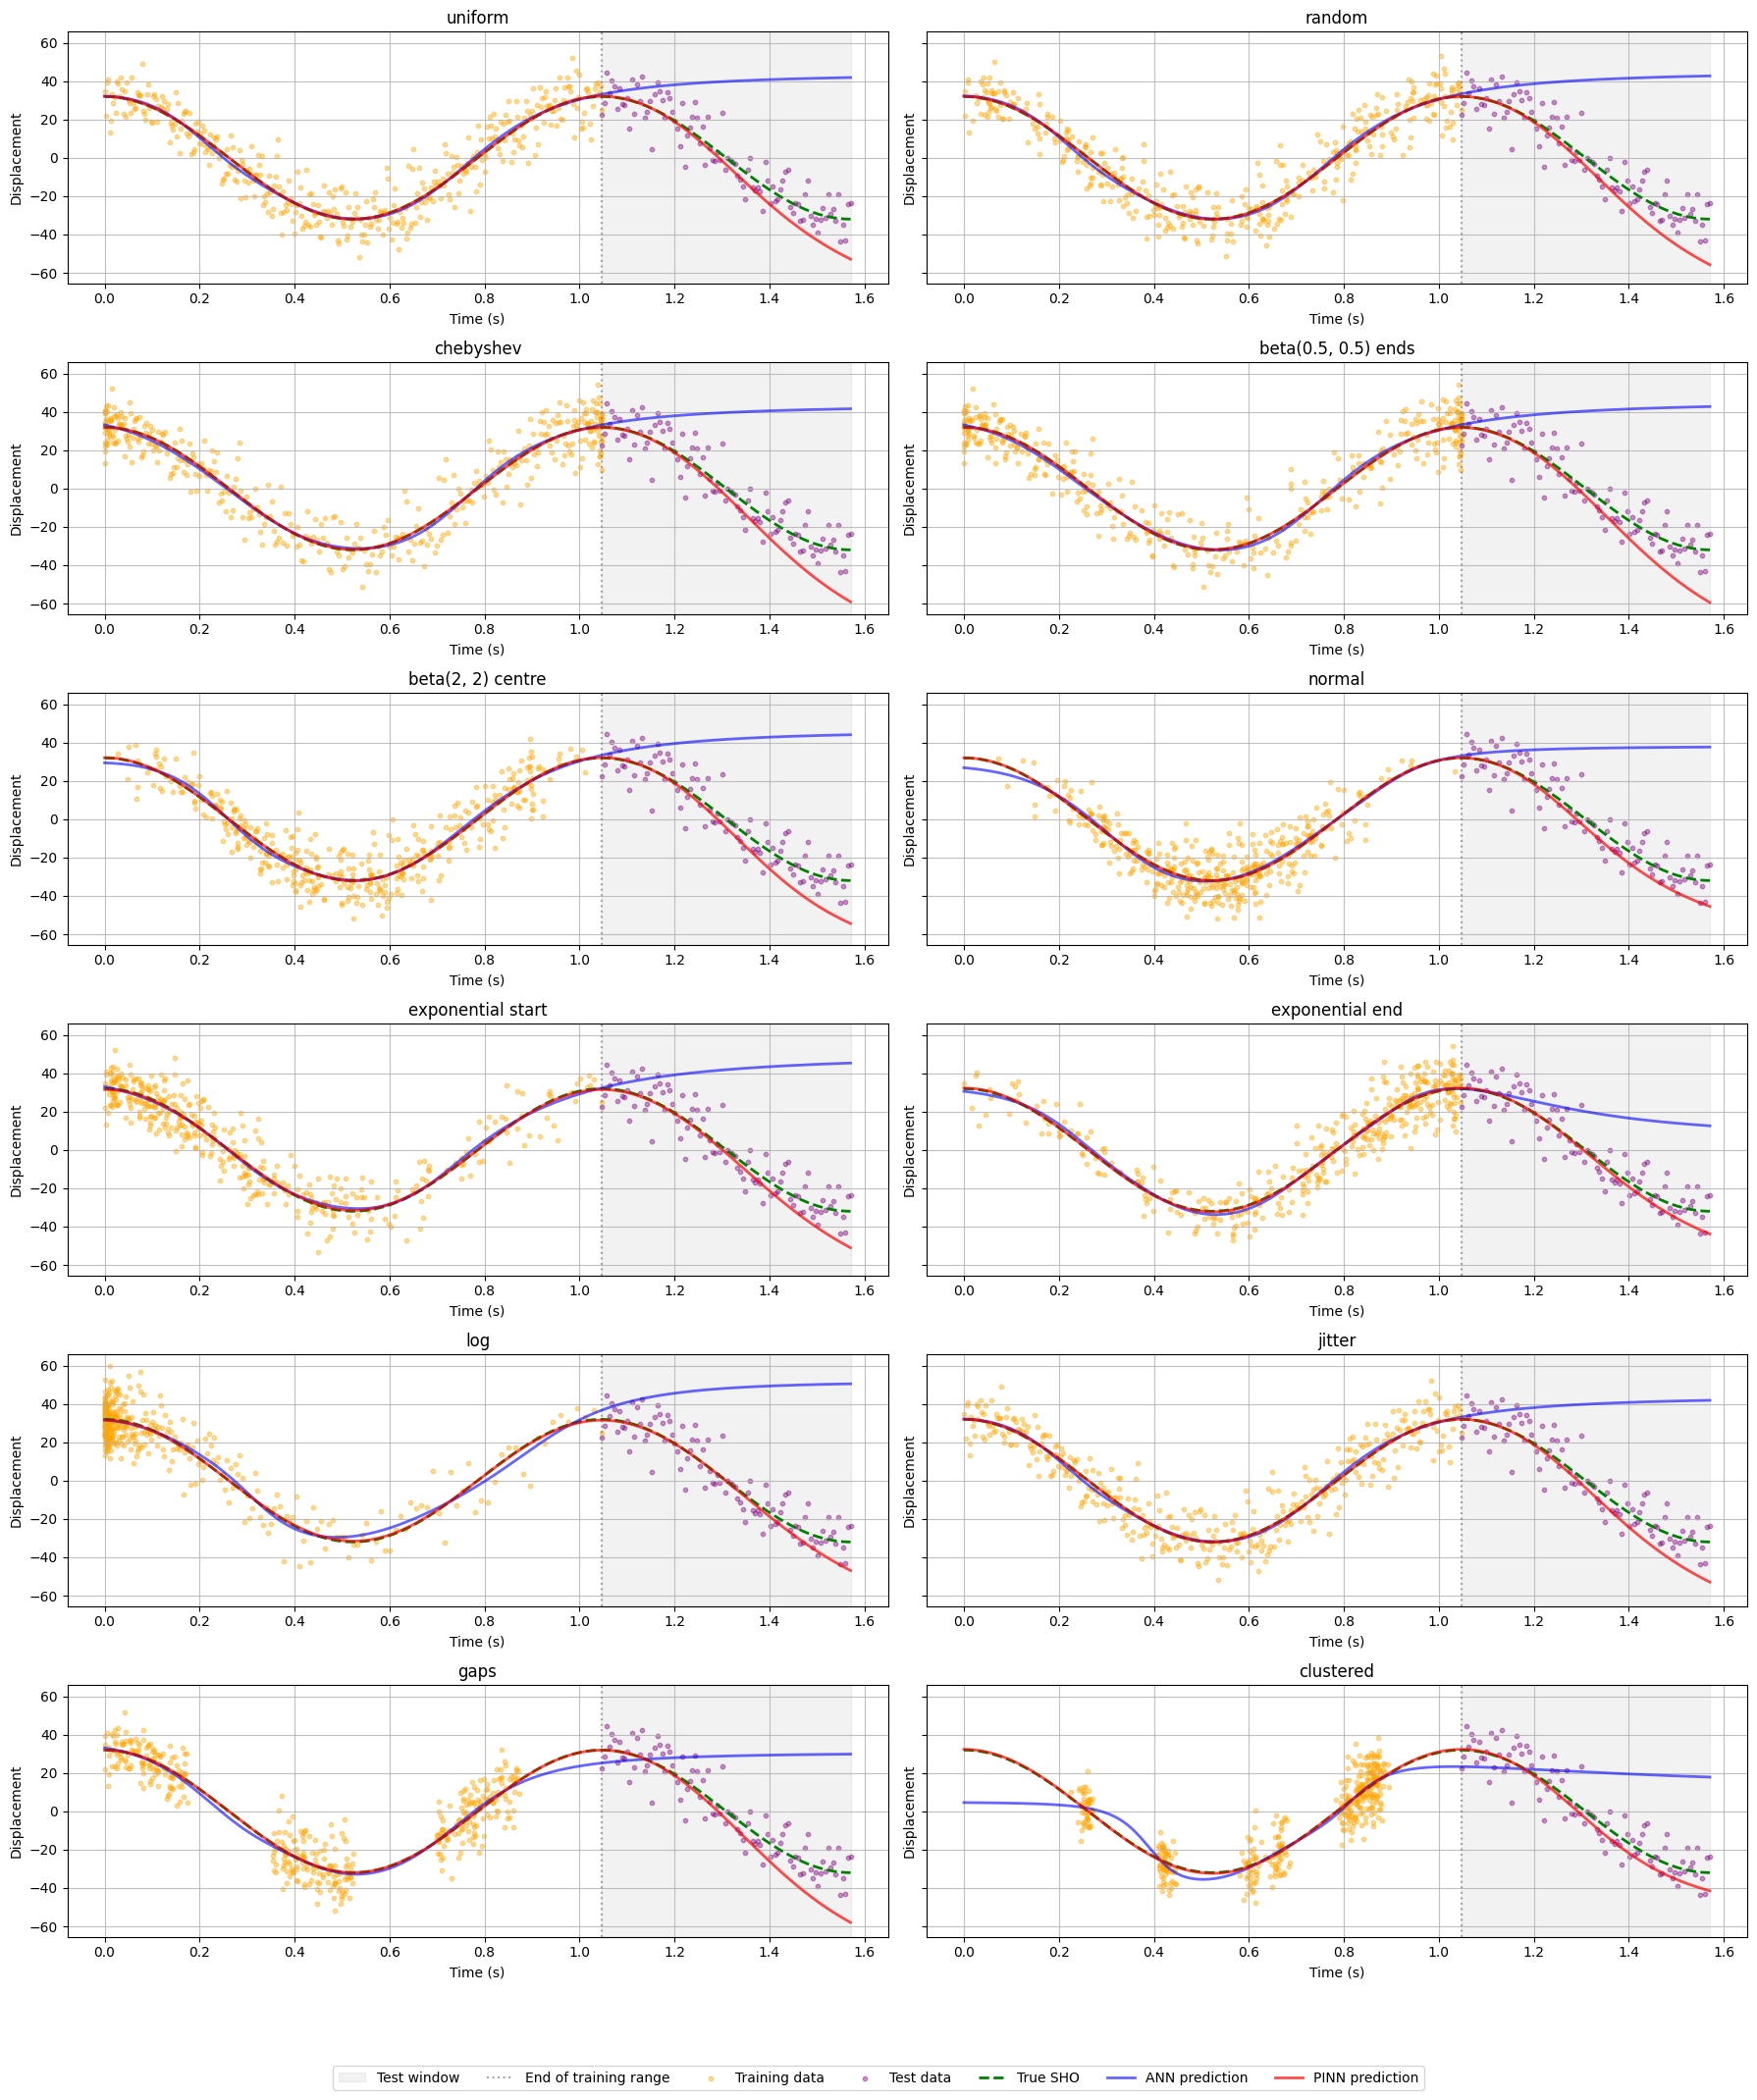

In [23]:
plot_predictions_grid(results, ncols=2)

#### Inspect one scheme in detail
Every entry of `results` is an `ExperimentResult`, so all the plots of Section 3 work on it.

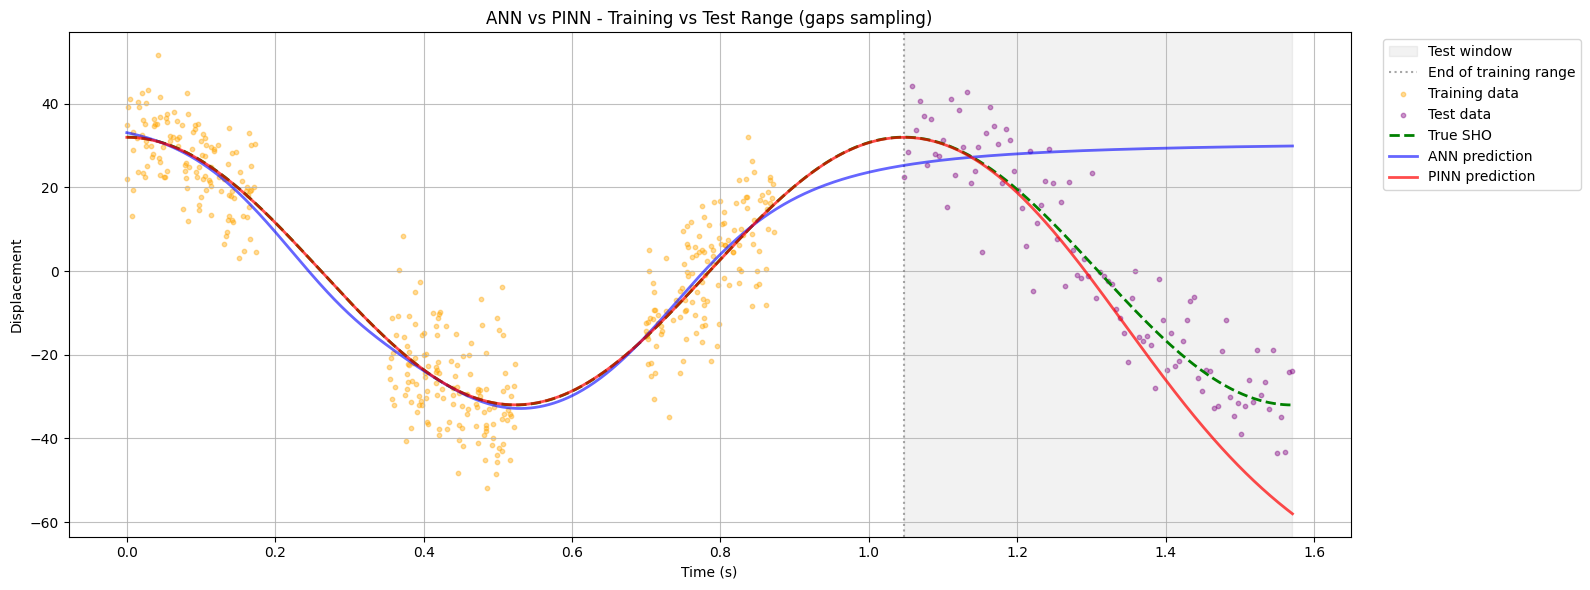

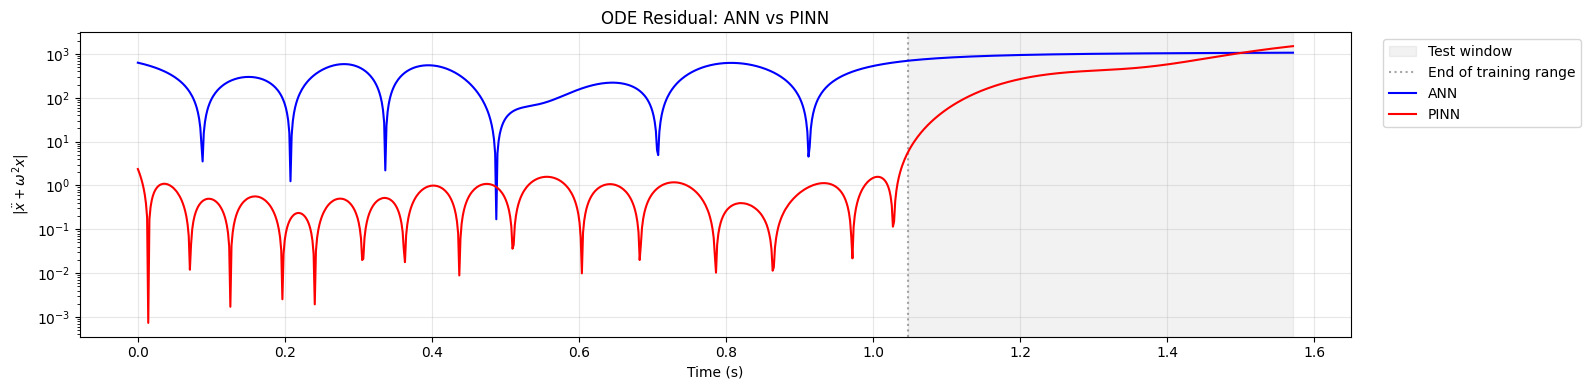

ANN                                PINN           \
                        MSE     RMSE      MAE      R2       MSE     RMSE   
Train (vs noisy)    82.8210   9.1006   7.2169  0.8611   83.3670   9.1306   
Train (vs true)      0.6214   0.7883   0.6518  0.9988    0.0010   0.0313   
Test (vs noisy)   1429.4334  37.8078  30.8762 -1.3564  194.3399  13.9406   
Test (vs true)    1383.4324  37.1945  29.9816 -1.6753  110.6235  10.5178   

                                   
                      MAE      R2  
Train (vs noisy)   7.2746  0.8602  
Train (vs true)    0.0275  1.0000  
Test (vs noisy)   10.9429  0.6796  
Test (vs true)     7.1927  0.7861

In [24]:
r = results["gaps"]
plot_predictions_full(r)
plot_ode_residual(r)
display(r.metrics.round(4))